In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

In [32]:
# Load immune cell fractions (assuming tab-separated format)
xcell_data = pd.read_csv("BRCA_xcell.tsv", sep="\t", index_col=0)

selected_cells = [
    "CD8_T_cells", "T cell CD4+ memory", "T cell CD4+ (non-regulatory)", "Endothelium", "Fibroblasts",
    "Mast cell", "Monocytes", "Dendritic_cells", "Macrophage M1", "Macrophage M2", "B_cells"
]

# Subset only the relevant immune cells
xcell_data  = xcell_data[selected_cells]
xcell_data.index = xcell_data.index.str[:-3] 
xcell_data_normalized = xcell_data.div(xcell_data.sum(axis=1), axis=0)

In [6]:
# Load CNV data from SKCM folder
cnv_data = pd.read_csv("BRCA_cnv_table_purity_rescale.txt", sep="\t", index_col=0)

# Standardize CNV column names
cnv_data.columns = cnv_data.columns.str.replace("^X", "", regex=True)

# Automatically compute thresholds based on quartiles
threshold_gain_1q = cnv_data["Arm1q"].quantile(0.75)  # Top 25% as Gain
threshold_loss_1q = cnv_data["Arm1q"].quantile(0.25)  # Bottom 25% as Loss

threshold_gain_9p = cnv_data["Arm9p"].quantile(0.75)  # Top 25% as Gain
threshold_loss_9p = cnv_data["Arm9p"].quantile(0.25)  # Bottom 25% as Loss

# Classify CNV values for Arm1q
cnv_data["CNV_Category_1q"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] >= threshold_gain_1q, "CNV_Category_1q"] = "Gain"
cnv_data.loc[cnv_data["Arm1q"] <= threshold_loss_1q, "CNV_Category_1q"] = "Loss"

# Classify CNV values for Arm9p
cnv_data["CNV_Category_9p"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] >= threshold_gain_9p, "CNV_Category_9p"] = "Gain"
cnv_data.loc[cnv_data["Arm9p"] <= threshold_loss_9p, "CNV_Category_9p"] = "Loss"


Unique CNV Categories for 1q: Index(['Gain', 'Loss', 'Neutral'], dtype='object', name='CNV_Category_1q')
Unique CNV Categories for 9p: Index(['Gain', 'Loss', 'Neutral'], dtype='object', name='CNV_Category_9p')


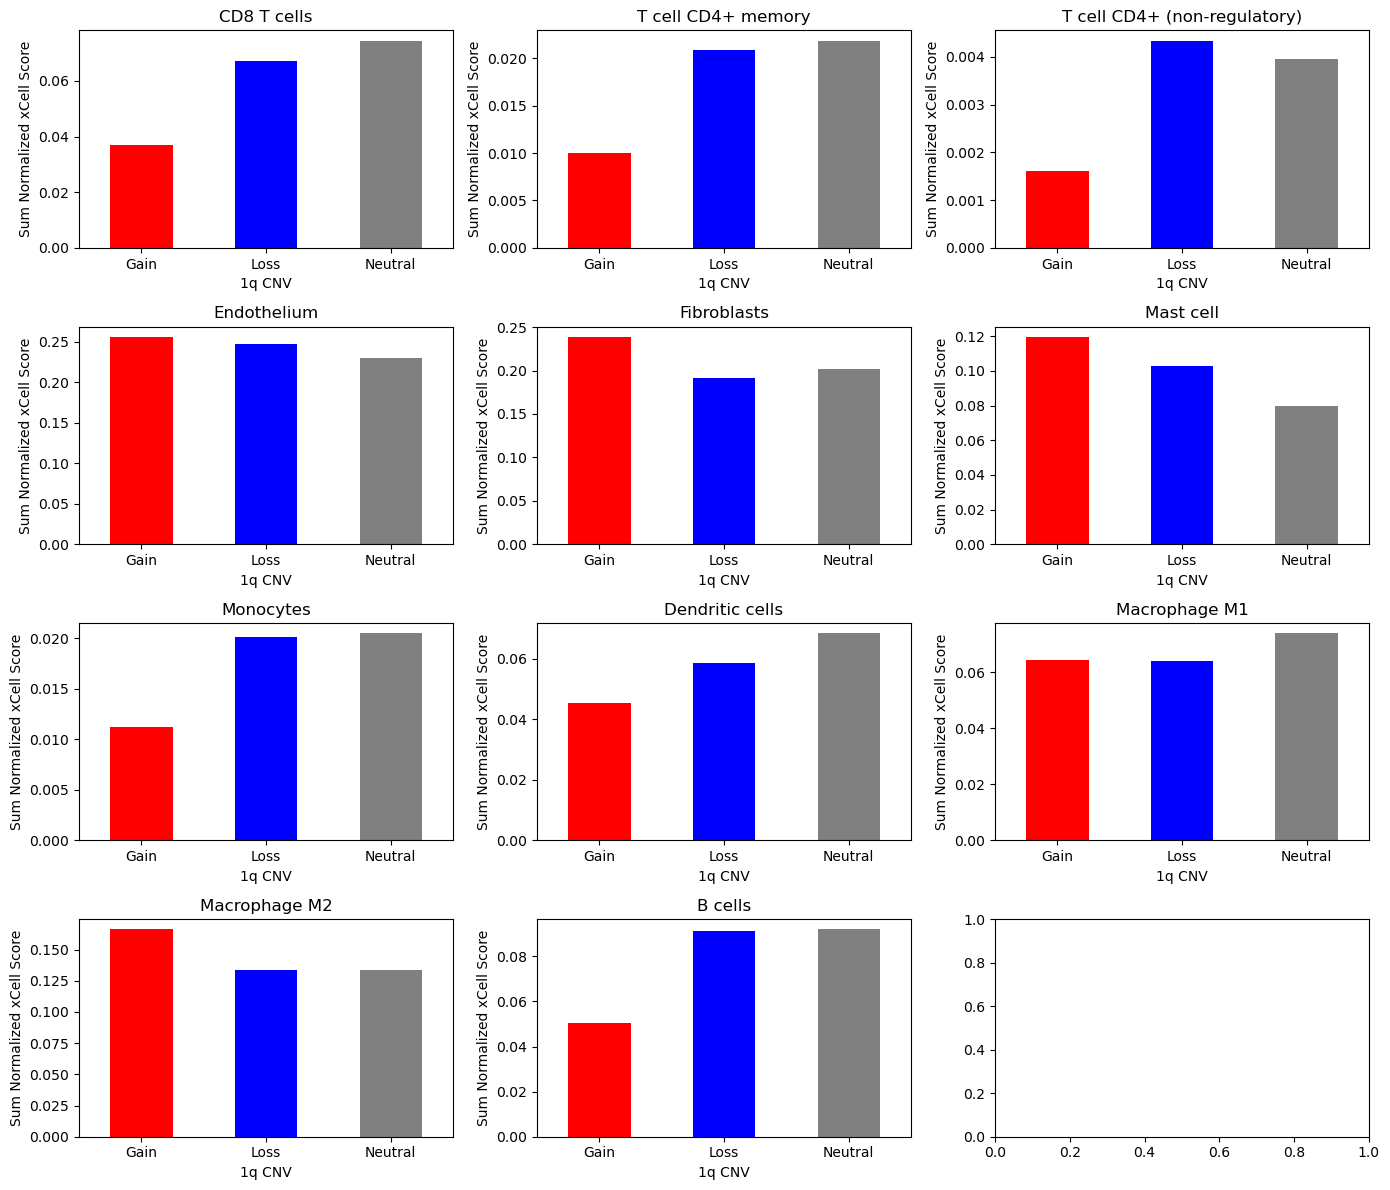

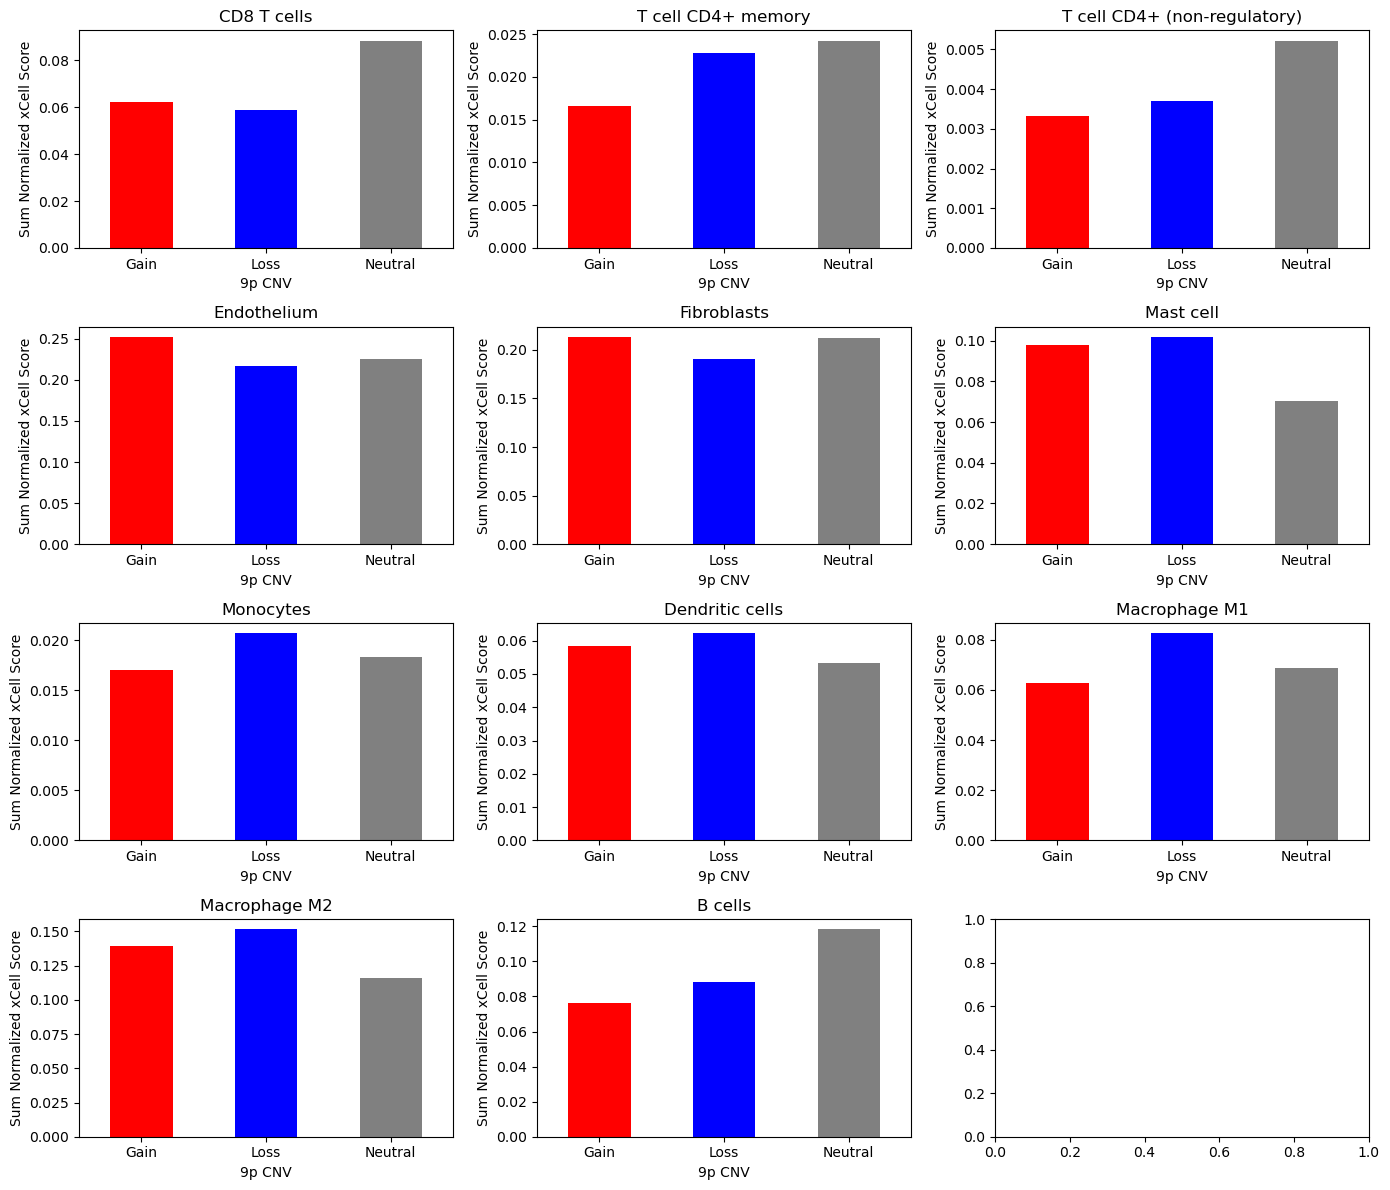

In [36]:
# Merge immune data with CNV classification
merged_data = xcell_data_normalized.join(cnv_data[["CNV_Category_1q", "CNV_Category_9p"]], how="inner")

# Compute mean immune scores per CNV category
immune_means_1q = merged_data.groupby("CNV_Category_1q")[selected_cells].mean()
immune_means_9p = merged_data.groupby("CNV_Category_9p")[selected_cells].mean()

# Debugging Step: Print Unique CNV Categories
print("Unique CNV Categories for 1q:", immune_means_1q.index.unique())
print("Unique CNV Categories for 9p:", immune_means_9p.index.unique())

# Define CNV colors
cnv_colors = {"Gain": "red", "Neutral": "gray", "Loss": "blue"}

# Plot Bar Charts for Each Cell Type (1q)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    immune_means_1q[cell].plot(kind="bar", color=[cnv_colors[x] for x in immune_means_1q.index], ax=axes[i])
    axes[i].set_title(cell.replace("_", " "))
    axes[i].set_xlabel("1q CNV")
    axes[i].set_ylabel("Sum Normalized xCell Score")
    axes[i].set_xticklabels(immune_means_1q.index, rotation=0)

plt.tight_layout()
plt.show()

# Plot Bar Charts for Each Cell Type (9p)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    immune_means_9p[cell].plot(kind="bar", color=[cnv_colors[x] for x in immune_means_9p.index], ax=axes[i])
    axes[i].set_title(cell.replace("_", " "))
    axes[i].set_xlabel("9p CNV")
    axes[i].set_ylabel("Sum Normalized xCell Score")
    axes[i].set_xticklabels(immune_means_9p.index, rotation=0)

plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_3334/1702409824.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cnv_numeric = merged_data[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})


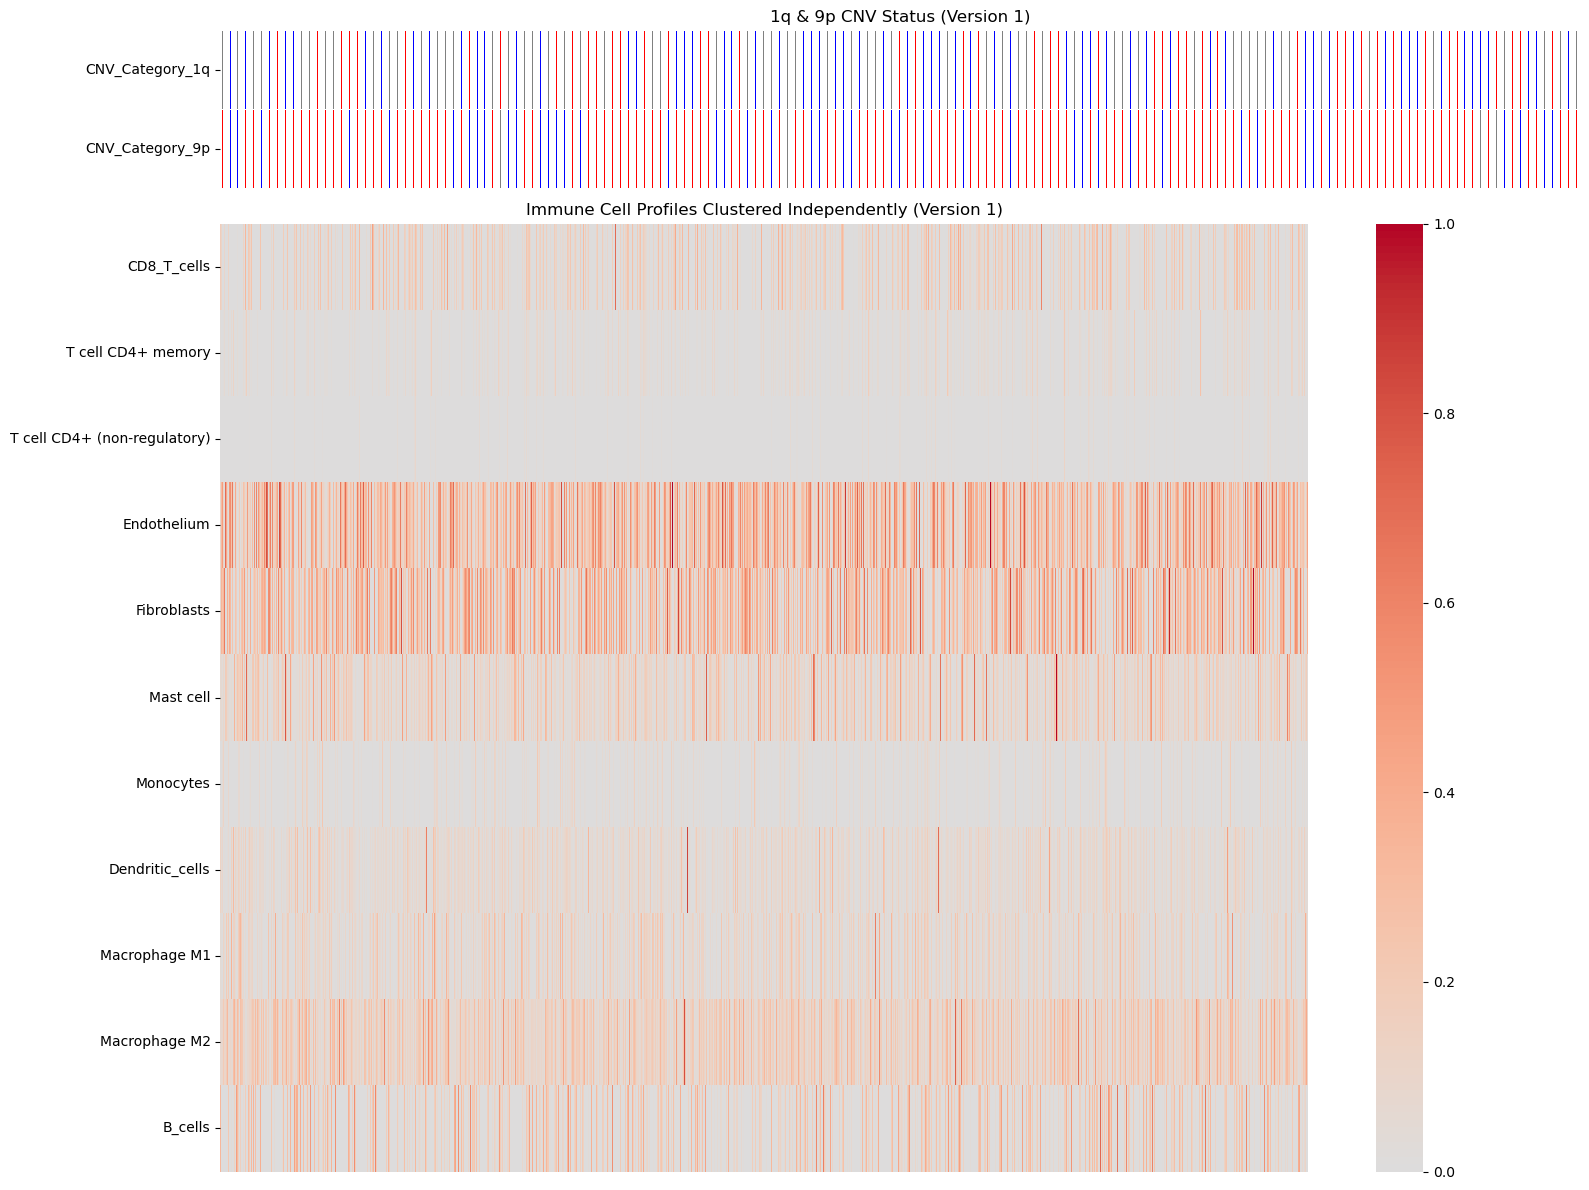

In [37]:
# Convert CNV categories to numeric values for heatmap
cnv_numeric = merged_data[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})

# ------------------------- Version 1: Cluster by Immune Cells Only -------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 6]})

# Plot CNV status on top (only for 1q & 9p)
sns.heatmap(cnv_numeric.T, cmap=["blue", "gray", "red"], cbar=False, ax=axes[0], linewidths=0.5, xticklabels=False)

# Plot immune data heatmap (Clustered by immune cells)
sns.heatmap(merged_data[selected_cells].T, cmap="coolwarm", center=0, ax=axes[1], xticklabels=False)

axes[0].set_title("1q & 9p CNV Status (Version 1)")
axes[1].set_title("Immune Cell Profiles Clustered Independently (Version 1)")

plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_3334/4170834520.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cnv_sorted_numeric = cnv_sorted[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})


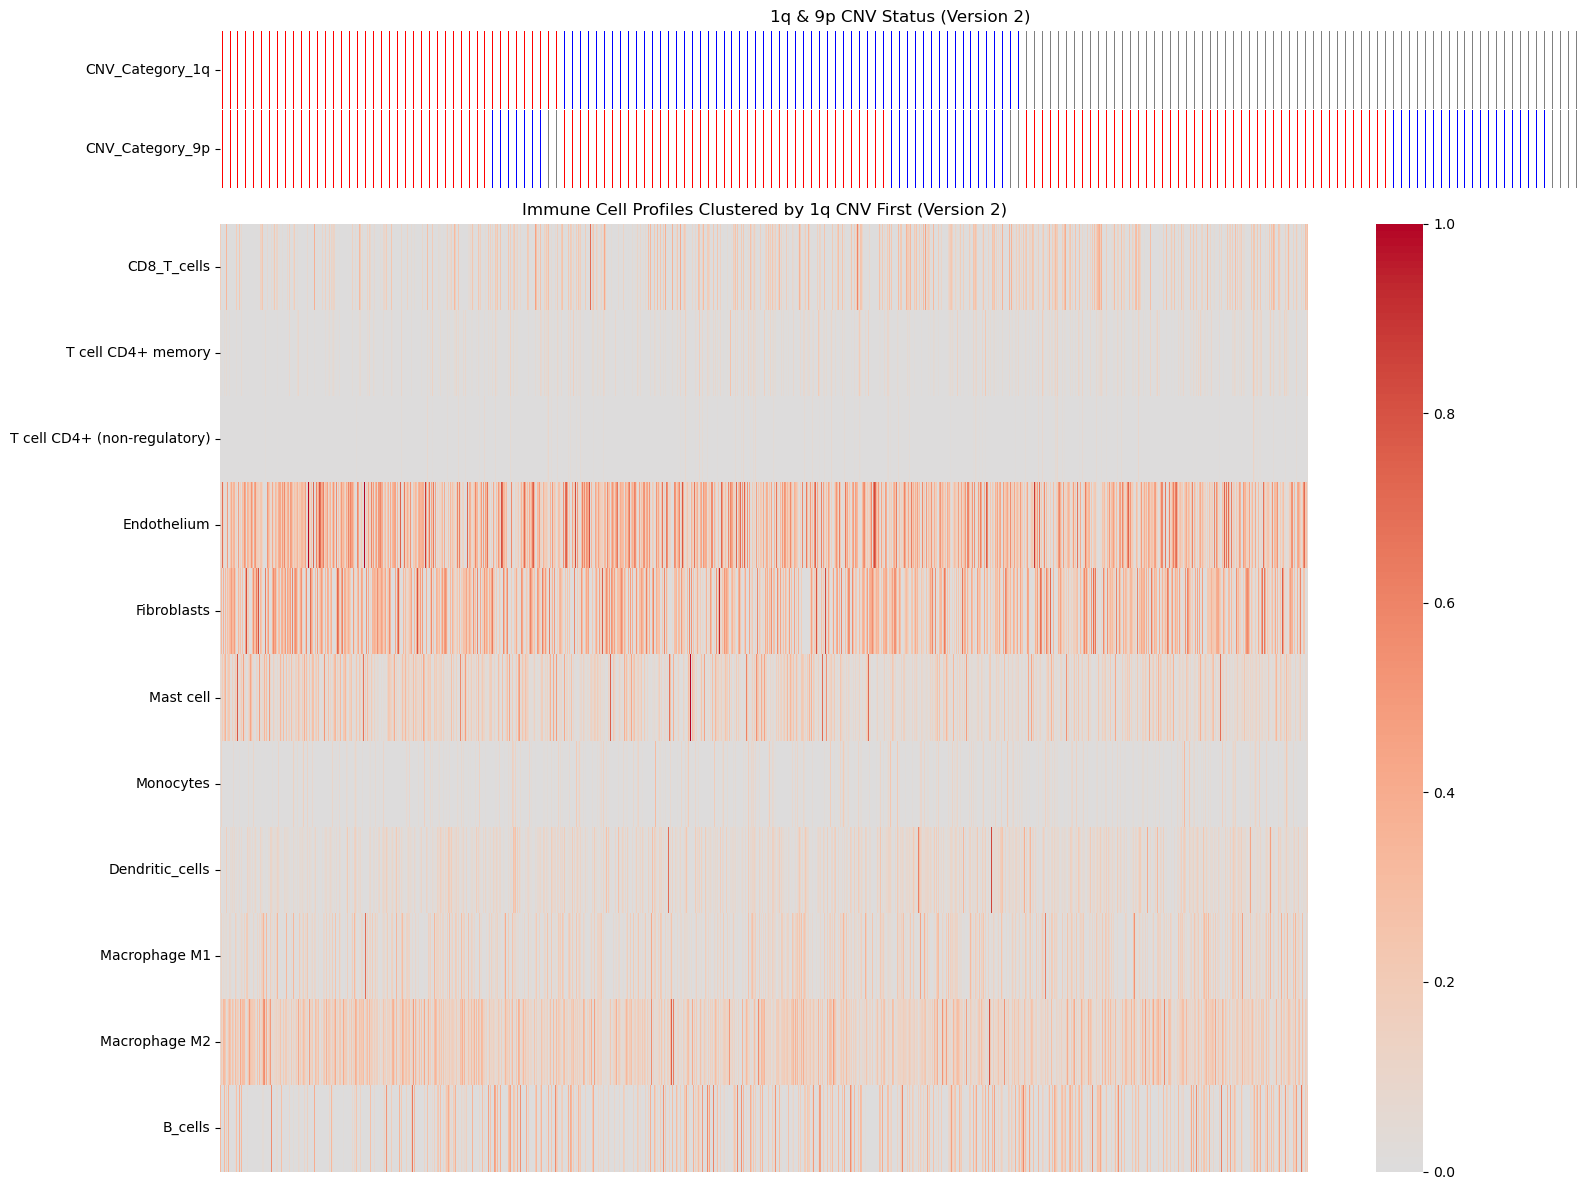

In [38]:
# ------------------------- Version 2: Cluster by CNV First, Then Immune Cells -------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 6]})

# Sort data first by CNV status
cnv_sorted = merged_data.sort_values(by=["CNV_Category_1q", "CNV_Category_9p"])

# Convert CNV categories to numerical values again
cnv_sorted_numeric = cnv_sorted[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})

# Plot CNV status on top
sns.heatmap(cnv_sorted_numeric.T, cmap=["blue", "gray", "red"], cbar=False, ax=axes[0], linewidths=0.5, xticklabels=False)

# Plot immune data heatmap (Clustered by CNV first)
sns.heatmap(cnv_sorted[selected_cells].T, cmap="coolwarm", center=0, ax=axes[1], xticklabels=False)

axes[0].set_title("1q & 9p CNV Status (Version 2)")
axes[1].set_title("Immune Cell Profiles Clustered by 1q CNV First (Version 2)")

plt.tight_layout()
plt.show()

In [13]:
# Check CNV Category assignments
print("1q CNV Distribution:\n", cnv_data["CNV_Category_1q"].value_counts())
print("9p CNV Distribution:\n", cnv_data["CNV_Category_9p"].value_counts())

1q CNV Distribution:
 CNV_Category_1q
Neutral    440
Loss       370
Gain       270
Name: count, dtype: int64
9p CNV Distribution:
 CNV_Category_9p
Gain       765
Loss       270
Neutral     45
Name: count, dtype: int64


In [14]:
# Print the computed quartiles
print("1q Gain Threshold:", cnv_data["Arm1q"].quantile(0.75))
print("1q Loss Threshold:", cnv_data["Arm1q"].quantile(0.25))

print("9p Gain Threshold:", cnv_data["Arm9p"].quantile(0.75))
print("9p Loss Threshold:", cnv_data["Arm9p"].quantile(0.25))

1q Gain Threshold: 0.841046561537544
1q Loss Threshold: 0.0
9p Gain Threshold: 0.0
9p Loss Threshold: -0.203855461247585


In [17]:
print("Missing CNV Data for 1q:\n", cnv_data["Arm1q"].isna().sum())
print("Missing CNV Data for 9p:\n", cnv_data["Arm9p"].isna().sum())

Missing CNV Data for 1q:
 0
Missing CNV Data for 9p:
 0


In [16]:
cnv_data = cnv_data.dropna(subset=["Arm1q", "Arm9p"])

In [21]:
print("Patients in CNV Data:", set(cnv_data.index))
print("Patients in Immune Data:", set(xcell_data.index))
print("Common Patients:", set(cnv_data.index).intersection(set(xcell_data.index)))

Patients in CNV Data: {'TCGA-E2-A150', 'TCGA-A1-A0SQ', 'TCGA-B6-A0IH', 'TCGA-A8-A06N', 'TCGA-B6-A0X0', 'TCGA-C8-A1HE', 'TCGA-AC-A2FF', 'TCGA-B6-A0WW', 'TCGA-AQ-A04H', 'TCGA-5L-AAT1', 'TCGA-BH-A202', 'TCGA-BH-AB28', 'TCGA-E2-A1LI', 'TCGA-A7-A0D9', 'TCGA-D8-A1X8', 'TCGA-AC-A2QI', 'TCGA-D8-A143', 'TCGA-AC-A7VC', 'TCGA-W8-A86G', 'TCGA-EW-A1J1', 'TCGA-3C-AAAU', 'TCGA-E2-A1L7', 'TCGA-AN-A0FX', 'TCGA-AR-A24X', 'TCGA-EW-A6SC', 'TCGA-AR-A2LN', 'TCGA-BH-A0HX', 'TCGA-B6-A0RM', 'TCGA-AR-A2LQ', 'TCGA-EW-A1J6', 'TCGA-EW-A1PF', 'TCGA-LL-A7SZ', 'TCGA-A2-A1G1', 'TCGA-A2-A25B', 'TCGA-AR-A24K', 'TCGA-A2-A0CL', 'TCGA-C8-A27B', 'TCGA-A8-A079', 'TCGA-B6-A0IE', 'TCGA-BH-A0DI', 'TCGA-AC-A62Y', 'TCGA-A2-A0T4', 'TCGA-B6-A1KC', 'TCGA-BH-A0W5', 'TCGA-BH-A0DQ', 'TCGA-BH-A0HB', 'TCGA-E2-A109', 'TCGA-D8-A1JB', 'TCGA-OL-A6VO', 'TCGA-AN-A0FT', 'TCGA-D8-A140', 'TCGA-AN-A04A', 'TCGA-B6-A2IU', 'TCGA-A8-A08F', 'TCGA-C8-A12U', 'TCGA-E2-A2P6', 'TCGA-D8-A1Y1', 'TCGA-E9-A249', 'TCGA-B6-A1KN', 'TCGA-E2-A14S', 'TCGA-A8-A06P', '

In [22]:
print("Unique CNV Categories for 1q:", cnv_data["CNV_Category_1q"].unique())
print("Unique CNV Categories for 9p:", cnv_data["CNV_Category_9p"].unique())

Unique CNV Categories for 1q: ['Loss' 'Neutral' 'Gain']
Unique CNV Categories for 9p: ['Loss' 'Gain' 'Neutral']


In [25]:
expected_categories = ["Gain", "Neutral", "Loss"]

# Ensure the index matches expected categories to avoid KeyErrors
immune_means_1q = immune_means_1q.reindex(expected_categories, fill_value=0)
immune_means_9p = immune_means_9p.reindex(expected_categories, fill_value=0)

print("After reindexing:")
print("Unique CNV Categories in immune_means_1q:", immune_means_1q.index.unique())
print("Unique CNV Categories in immune_means_9p:", immune_means_9p.index.unique())

After reindexing:
Unique CNV Categories in immune_means_1q: Index(['Gain', 'Neutral', 'Loss'], dtype='object', name='CNV_Category_1q')
Unique CNV Categories in immune_means_9p: Index(['Gain', 'Neutral', 'Loss'], dtype='object', name='CNV_Category_9p')


In [30]:
# Check if CNV categories are valid before applying colors
valid_categories = immune_means.index.intersection(cnv_colors.keys())  # Filter known categories
immune_means = immune_means.loc[valid_categories]  # Keep only known categories

# Plot Bar Charts for Each Cell Type (1q)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    # Use get() to avoid KeyErrors if unexpected CNV categories appear
    colors = [cnv_colors.get(x, "black") for x in immune_means.index]
    
    immune_means[cell].plot(kind="bar", color=colors, ax=axes[i])
    
    # Formatting
    axes[i].set_title(cell.replace("_", " "))  # Clean labels
    axes[i].set_xlabel("1q CNV")
    axes[i].set_ylabel("xCell Score")
    axes[i].set_xticklabels(immune_means.index, rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'immune_means' is not defined